In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

import copy


In [6]:
df = pd.read_csv("/Users/svelebasergij/Desktop/мн_4/synthetic_coffee_health_10000.csv")
df.head()



,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [7]:
# видаляємо ID, якщо він є:
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# цільова змінна
target_col = "Health_Issues"
y = df[target_col]
X = df.drop(columns=[target_col])

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

categorical_features, numeric_features

print("Числові ознаки:", numeric_features)
print("Категоріальні ознаки:", categorical_features)




Числові ознаки: ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption']
Категоріальні ознаки: ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation']


In [8]:
# One-hot кодування категоріальних ознак
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Обʼєднуємо X та y, потім ще раз прибираємо NaN, раптом десь лишились
data = X_encoded.copy()
data[target_col] = y

data = data.dropna()

X_final = data.drop(columns=[target_col])
y_final = data[target_col]

print("Розмірність X_final:", X_final.shape)
print("Кількість класів у y_final:", y_final.nunique())
print(y_final.value_counts())


Розмірність X_final: (4059, 39)
Кількість класів у y_final: 3
Health_Issues
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64


In [9]:
# Остаточний поділ на train / val / test (зараз вже без NaN)тренувальний, валідаційний та тестовий
X_temp, X_test, y_temp, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Train: (2435, 39)
Val:   (812, 39)
Test:  (812, 39)


In [10]:
class MyDecisionTree:   #реалізація дерева рішень
    def __init__(self, max_depth=5, min_samples=2):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.feature_importance = None
        self.tree = None
        self.n_total = None

    # Gini-індекс .чим менше, тим чистіше розділення (менше змішаних класів).
    def gini(self, y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        prob = counts / len(y)
        return 1.0 - np.sum(prob ** 2)

    # Пошук найкращого спліта\ найкращого поділу
    def best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_gini = self.gini(y)

        best_gini = float("inf")
        best_feature = None
        best_thr = None
        best_left = None
        best_right = None

        for f in range(n_features):
            values = X[:, f]
            thresholds = np.unique(values)

            for t in thresholds:
                left = values <= t
                right = values > t

                if left.sum() < self.min_samples or right.sum() < self.min_samples:
                    continue

                g_left = self.gini(y[left])
                g_right = self.gini(y[right])

                g_split = (left.sum()/n_samples)*g_left + (right.sum()/n_samples)*g_right

                if g_split < best_gini:
                    best_gini = g_split
                    best_feature = f
                    best_thr = t
                    best_left = left
                    best_right = right

        if best_feature is None:
            return None, None, None, None, None, None

        impurity_decrease = parent_gini - best_gini

        return best_feature, best_thr, best_left, best_right, best_gini, impurity_decrease

    # Рекурсивна побудова дерева
    def build_tree(self, X, y, depth=0):
        n_samples = len(y)
        classes, counts = np.unique(y, return_counts=True)
        majority = classes[np.argmax(counts)]

        # критерії зупинки
        if (depth >= self.max_depth or
            n_samples < self.min_samples or
            len(classes) == 1):
            return {"leaf": True, "class": majority}

        feature, thr, left, right, best_gini, impurity_dec = self.best_split(X, y)

        if feature is None:
            return {"leaf": True, "class": majority}

        # оновлюємо важливість: зменшення джіні * частка вибірки у вузлі
        self.feature_importance[feature] += impurity_dec * (n_samples / self.n_total)

        left_sub = self.build_tree(X[left], y[left], depth + 1)
        right_sub = self.build_tree(X[right], y[right], depth + 1)

        return {
            "leaf": False,
            "feature": feature,
            "threshold": thr,
            "left": left_sub,
            "right": right_sub,
            "class": majority,
            "impurity_decrease": impurity_dec
        }

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.n_total = len(y)
        self.feature_importance = np.zeros(X.shape[1])
        self.tree = self.build_tree(X, y)
        s = self.feature_importance.sum()
        if s > 0:
            self.feature_importance /= s
        return self

    # прогноз для одного об’єкта
    def predict_one(self, x, node=None):
        if node is None:
            node = self.tree
        if node["leaf"]:
            return node["class"]
        if x[node["feature"]] <= node["threshold"]:
            return self.predict_one(x, node["left"])
        else:
            return self.predict_one(x, node["right"])

    # прогноз для багатьох
    def predict(self, X):
        X = np.array(X)
        return np.array([self.predict_one(row) for row in X])

    # допоміжне – помилка вузла
    def calculate_error(self, X, y, node):
        X = np.array(X)
        y = np.array(y)
        preds = np.array([self.predict_one(x, node) for x in X])
        return np.sum(preds != y)

    # кількість листів
    def count_leaves(self, node):
        if node["leaf"]:
            return 1
        return self.count_leaves(node["left"]) + self.count_leaves(node["right"])

    # cost-complexity прунінг
    def prune_tree(self, node, X_val, y_val, alpha):
        X_val = np.array(X_val)
        y_val = np.array(y_val)

        if node["leaf"]:
            return self.calculate_error(X_val, y_val, node)

        f = node["feature"]
        t = node["threshold"]

        left_mask = X_val[:, f] <= t
        right_mask = ~left_mask

        left_err = self.prune_tree(node["left"], X_val[left_mask], y_val[left_mask], alpha)
        right_err = self.prune_tree(node["right"], X_val[right_mask], y_val[right_mask], alpha)

        subtree_err = left_err + right_err
        leaves_subtree = self.count_leaves(node)

        # варіант: згорнути піддерево в лист
        leaf_node = {"leaf": True, "class": node["class"]}
        leaf_err = self.calculate_error(X_val, y_val, leaf_node)

        # cost = error + alpha * #leaves
        cost_subtree = subtree_err + alpha * leaves_subtree
        cost_leaf = leaf_err + alpha * 1

        if cost_leaf <= cost_subtree:
            # обрізаємо
            node.clear()
            node.update(leaf_node)
            return leaf_err
        else:
            return subtree_err


In [11]:
tree = MyDecisionTree(max_depth=6, min_samples=20)
tree.fit(X_train.values, y_train.values)

y_pred_train = tree.predict(X_train.values)
y_pred_test = tree.predict(X_test.values)

print("=== MyDecisionTree (до прунінгу) ===")
print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy: ", accuracy_score(y_test, y_pred_test))
print("F1 macro:      ", f1_score(y_test, y_pred_test, average='macro'))
print("MCC:           ", matthews_corrcoef(y_test, y_pred_test))

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification report (test):")
print(classification_report(y_test, y_pred_test))


=== MyDecisionTree (до прунінгу) ===
Train accuracy: 0.9930184804928132
Test accuracy:  0.9889162561576355
F1 macro:       0.8162401006474015
MCC:            0.9482819202992232

Confusion matrix (test):
[[713   3   0]
 [  0  87   6]
 [  0   0   3]]

Classification report (test):
              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       716
    Moderate       0.97      0.94      0.95        93
      Severe       0.33      1.00      0.50         3

    accuracy                           0.99       812
   macro avg       0.77      0.98      0.82       812
weighted avg       0.99      0.99      0.99       812



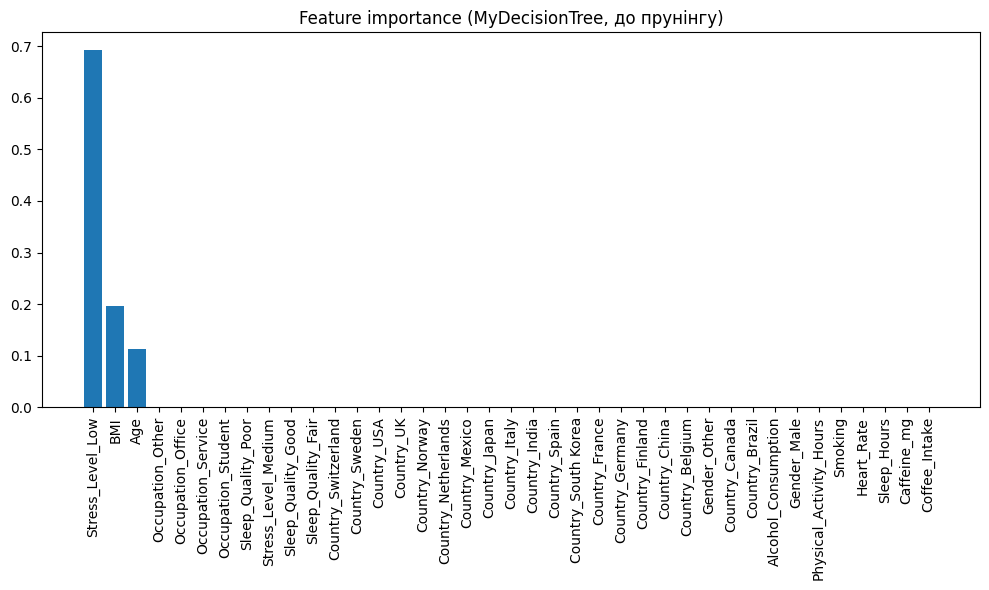

In [12]:
importances = tree.feature_importance
feature_names = X_final.columns
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[idx])
plt.xticks(range(len(importances)), feature_names[idx], rotation=90)
plt.title("Feature importance (MyDecisionTree, до прунінгу)")
plt.tight_layout()
plt.show()


In [13]:
#обрізаємо піддерева, які мало впливають на якість, але ускладнюють дерево.
alpha = 0.001  

tree_pruned = tree 
tree_pruned.prune_tree(tree_pruned.tree, X_val.values, y_val.values, alpha)

y_pred_test_pruned = tree_pruned.predict(X_test.values)

print("=== MyDecisionTree (після прунінгу) ===")
print("Test accuracy:", accuracy_score(y_test, y_pred_test_pruned))
print("F1 macro:    ", f1_score(y_test, y_pred_test_pruned, average='macro'))
print("MCC:         ", matthews_corrcoef(y_test, y_pred_test_pruned))

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, y_pred_test_pruned))

print("\nClassification report (test):")
print(classification_report(y_test, y_pred_test_pruned))


=== MyDecisionTree (після прунінгу) ===
Test accuracy: 0.9926108374384236
F1 macro:     0.6555502099370188
MCC:          0.9653553993248246

Confusion matrix (test):
[[713   3   0]
 [  0  93   0]
 [  0   3   0]]

Classification report (test):
              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       716
    Moderate       0.94      1.00      0.97        93
      Severe       0.00      0.00      0.00         3

    accuracy                           0.99       812
   macro avg       0.65      0.67      0.66       812
weighted avg       0.99      0.99      0.99       812



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [ ]:
# sklearn DecisionTree порівнюємо  ручну реалізацію дерева рішень із професійною з sklearn
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== sklearn DecisionTree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("F1 macro:", f1_score(y_test, y_pred_dt, average='macro'))
print("MCC:", matthews_corrcoef(y_test, y_pred_dt))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_dt))


=== sklearn DecisionTree ===
Accuracy: 0.9889162561576355
F1 macro: 0.8162401006474015
MCC: 0.9482819202992232
Confusion matrix:
 [[713   3   0]
 [  0  87   6]
 [  0   0   3]]


In [ ]:
# RandomForest
rf = RandomForestClassifier(
    n_estimators=100,   # кількість дерев
    criterion="gini",   # як міряється якість розбиття
    random_state=42,    # для стабільних результатів
    n_jobs=-1           # використовувати всі ядра CPU
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RandomForest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 macro:", f1_score(y_test, y_pred_rf, average='macro'))
print("MCC:", matthews_corrcoef(y_test, y_pred_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))


=== RandomForest ===
Accuracy: 0.979064039408867
F1 macro: 0.631058420601989
MCC: 0.8964179396096301
Confusion matrix:
 [[716   0   0]
 [ 14  79   0]
 [  0   3   0]]


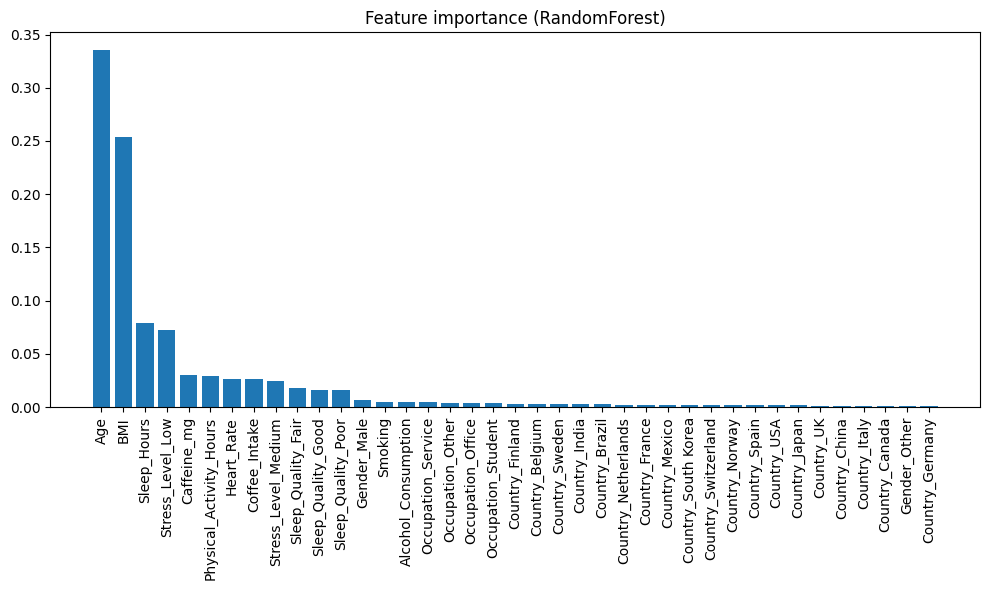

In [22]:
# Важливість ознак RandomForest
rf_importances = rf.feature_importances_
idx_rf = np.argsort(rf_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(rf_importances)), rf_importances[idx_rf])
plt.xticks(range(len(rf_importances)), feature_names[idx_rf], rotation=90)
plt.title("Feature importance (RandomForest)")
plt.tight_layout()
plt.show()


In [ ]:
df_fe = df.copy()  # тут df вже без NaN в Health_Issues

# Нова взаємодія: Coffee_Intake * Sleep_Hours (якщо колонки є)
if {"Coffee_Intake", "Sleep_Hours"}.issubset(df_fe.columns):
    df_fe["Coffee_Sleep_Interaction"] = df_fe["Coffee_Intake"] * df_fe["Sleep_Hours"]

# Розбиття віку на категорії (бінінг)
if "Age" in df_fe.columns:
    df_fe["Age_Binned"] = pd.cut(
        df_fe["Age"],
        bins=[18, 30, 50, 80],
        labels=["Young", "Middle", "Old"],
        include_lowest=True
    )

y_fe = df_fe[target_col]
X_fe = df_fe.drop(columns=[target_col])

cat_fe = X_fe.select_dtypes(exclude=[np.number]).columns.tolist()
num_fe = X_fe.select_dtypes(include=[np.number]).columns.tolist()

X_fe_enc = pd.get_dummies(X_fe, columns=cat_fe, drop_first=True)

# нормалізація числових
scaler = StandardScaler()
num_cols_fe = [col for col in X_fe_enc.columns if col in num_fe]
X_fe_enc[num_cols_fe] = scaler.fit_transform(X_fe_enc[num_cols_fe])

# прибираємо NaN, якщо вони виникли
data_fe = X_fe_enc.copy()
data_fe[target_col] = y_fe
data_fe = data_fe.dropna()

X_fe_final = data_fe.drop(columns=[target_col])
y_fe_final = data_fe[target_col]

print("Розмірність X_fe_final:", X_fe_final.shape)


Розмірність X_fe_final: (4059, 42)


In [24]:
# train / test для інженерованих ознак
X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe_final, y_fe_final,
    test_size=0.2,
    random_state=42,
    stratify=y_fe_final
)

tree_fe = MyDecisionTree(max_depth=6, min_samples=20)
tree_fe.fit(X_fe_train.values, y_fe_train.values)

y_fe_pred = tree_fe.predict(X_fe_test.values)

print("=== MyDecisionTree на інженерованих ознаках ===")
print("Accuracy:", accuracy_score(y_fe_test, y_fe_pred))
print("F1 macro:", f1_score(y_fe_test, y_fe_pred, average='macro'))
print("MCC:", matthews_corrcoef(y_fe_test, y_fe_pred))


=== MyDecisionTree на інженерованих ознаках ===
Accuracy: 0.9950738916256158
F1 macro: 0.9090320074191043
MCC: 0.976788299947962


In [25]:
# Топ-10 ознак за важливістю
importances_fe = tree_fe.feature_importance
idx_fe = np.argsort(importances_fe)[::-1]
top_k = 10
top_idx = idx_fe[:top_k]
top_features = X_fe_final.columns[top_idx]
print("Top-10 ознак:\n", top_features)


Top-10 ознак:
 Index(['Stress_Level_Low', 'BMI', 'Age', 'Occupation_Student',
       'Age_Binned_Middle', 'Occupation_Service', 'Occupation_Office',
       'Stress_Level_Medium', 'Occupation_Other', 'Age_Binned_Old'],
      dtype='object')


In [26]:
# RandomForest тільки на топ-10 ознаках
X_top = X_fe_final[top_features]

X_top_train, X_top_test, y_top_train, y_top_test = train_test_split(
    X_top, y_fe_final,
    test_size=0.2,
    random_state=42,
    stratify=y_fe_final
)

rf_top = RandomForestClassifier(n_estimators=100, random_state=42)
rf_top.fit(X_top_train, y_top_train)
y_top_pred = rf_top.predict(X_top_test)

print("=== RandomForest на топ-10 ознаках ===")
print("Accuracy:", accuracy_score(y_top_test, y_top_pred))
print("F1 macro:", f1_score(y_top_test, y_top_pred, average='macro'))
print("MCC:", matthews_corrcoef(y_top_test, y_top_pred))


=== RandomForest на топ-10 ознаках ===
Accuracy: 0.9938423645320197
F1 macro: 0.9896320731624484
MCC: 0.9703496774891308
